In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

from scipy import stats

df = pd.read_csv("cardio_train.csv", sep=";")
display(df.head())

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


dataset shape:

Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB

Missing Values:


id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

Summary statistics:


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,28851.302323,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,25006.750000,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,50001.500000,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,74889.250000,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000



Preview of new variables:


,age,age_years,height,weight,bmi,ap_hi,ap_lo
0,18393,50.357290,168,62.0,21.967120,110,80
1,20228,55.381246,156,85.0,34.927679,140,90
2,18857,51.627652,165,64.0,23.507805,130,70
3,17623,48.249144,169,82.0,28.710479,150,100
4,17474,47.841205,156,56.0,23.011177,100,60


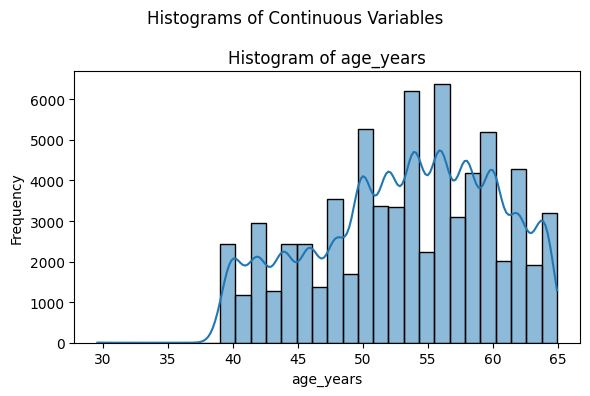

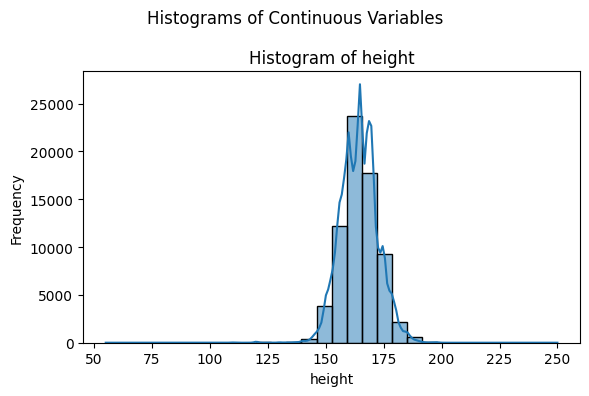

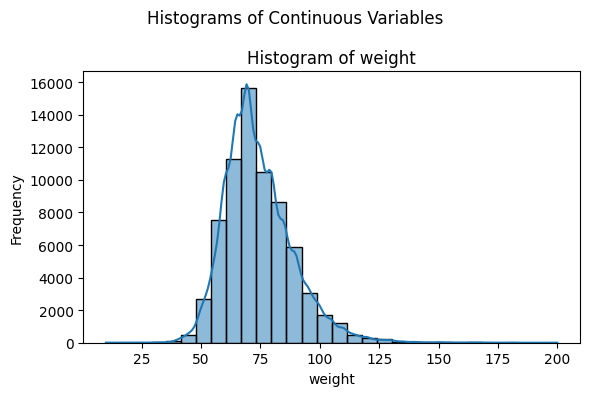

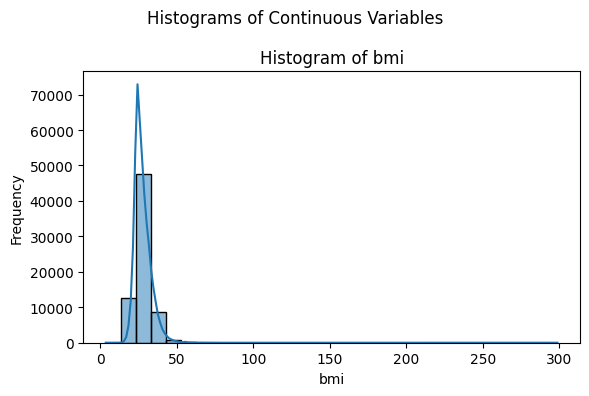

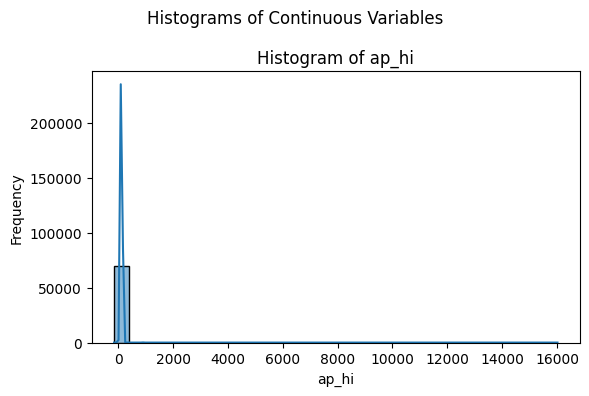

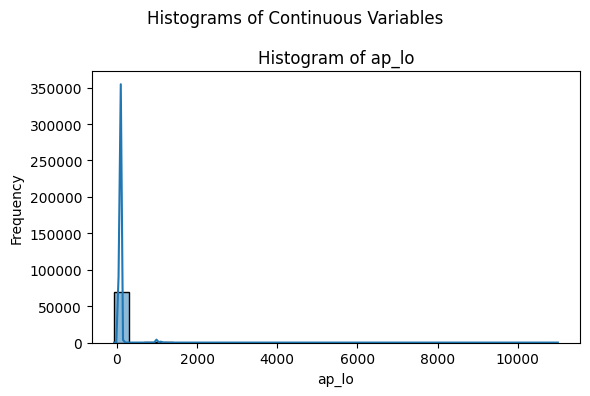

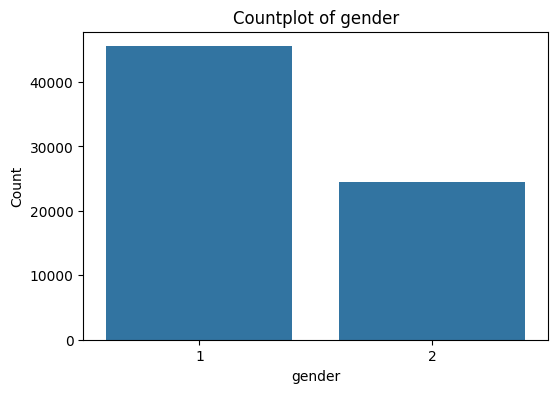

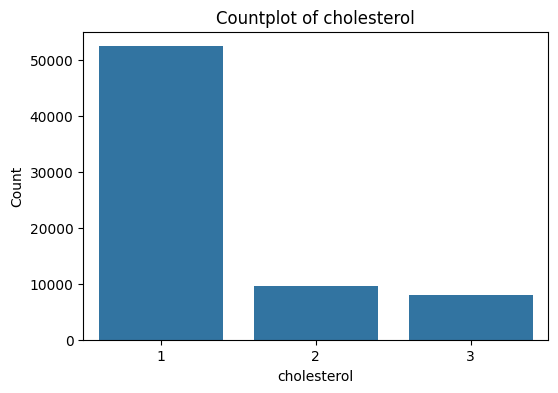

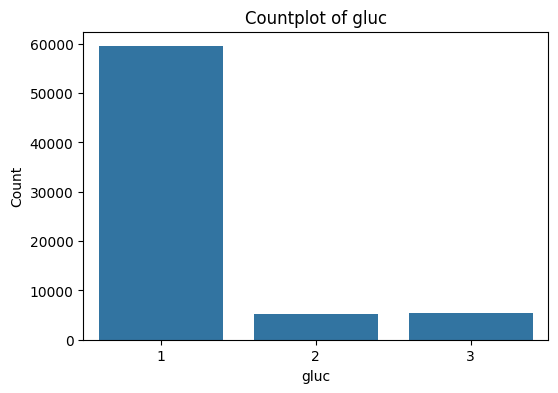

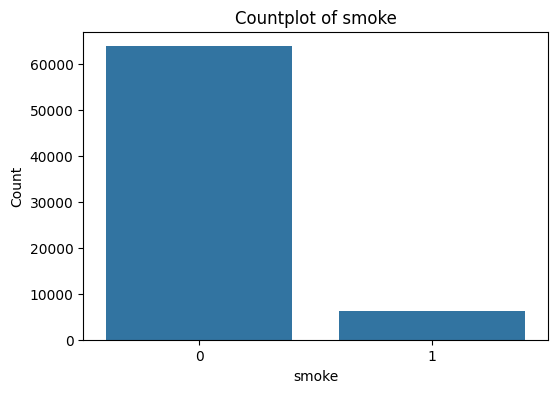

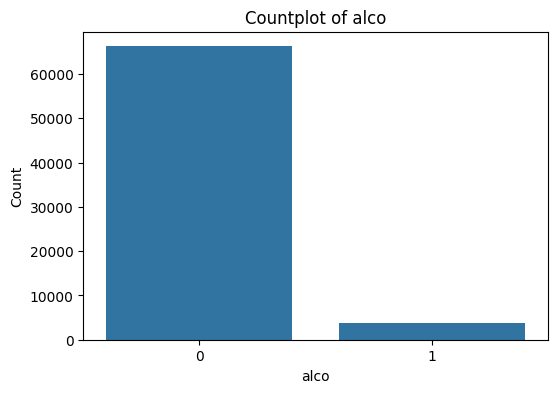

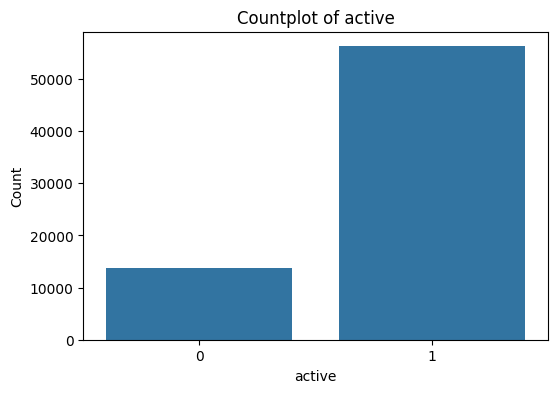

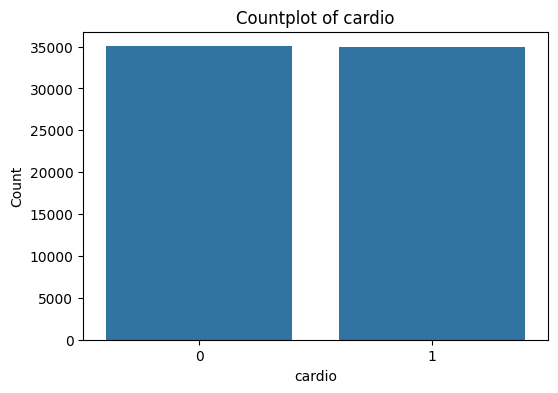

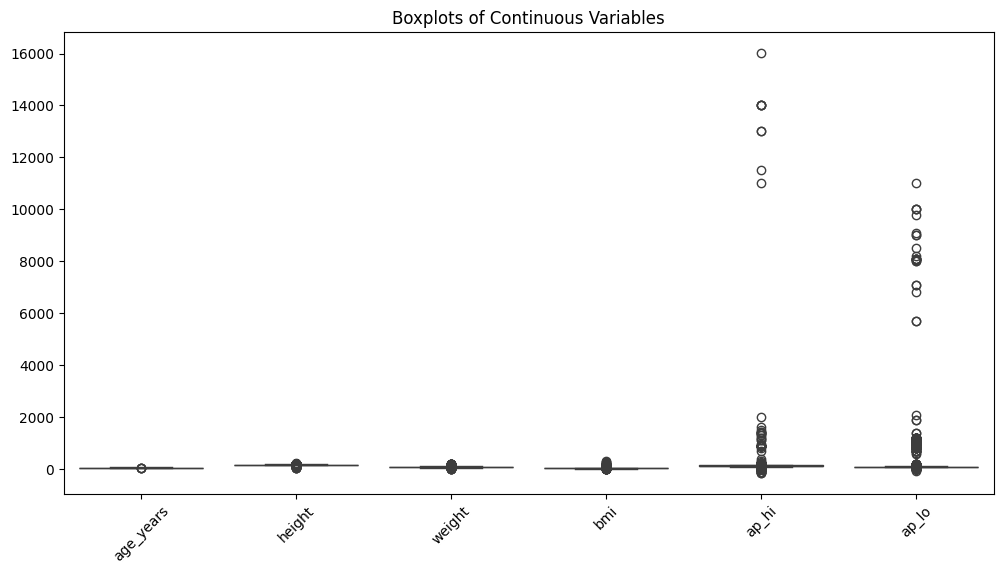

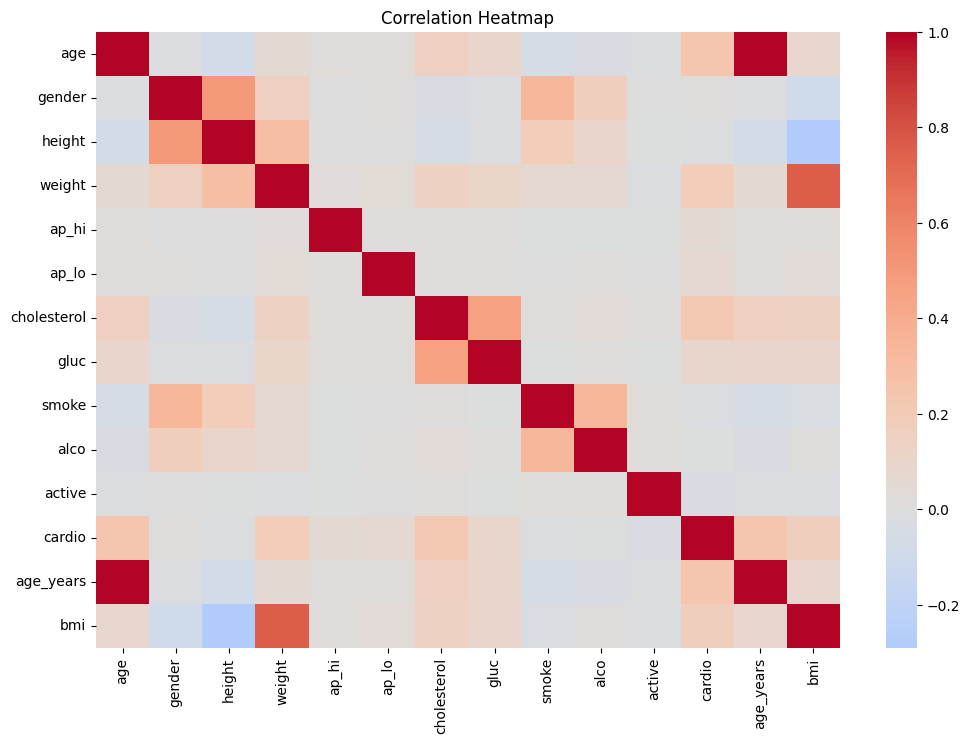

In [7]:
## Part 1 EDA
print("dataset shape:")
df.shape
print("\nDataset info:")
df.info()
print("\nMissing Values:")
display(df.isnull().sum())
print("Summary statistics:")
display(df.describe())

#easier to read variables
df["age_years"] = df["age"] / 365.25
df["bmi"] = df["weight"] / ((df["height"] / 100) ** 2) 
print("\nPreview of new variables:")
display(df[["age", "age_years", "height", "weight", "bmi", "ap_hi", "ap_lo"]].head())

#continuous variables
continuous_cols = ["age_years", "height", "weight", "bmi","ap_hi","ap_lo"]

#histograms
for col in continuous_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.suptitle("Histograms of Continuous Variables")
    plt.tight_layout()
    plt.show()

##categorical variables
categorical_cols = ["gender", "cholesterol", "gluc", "smoke", "alco", "active", "cardio"]
##countplots
for col in categorical_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, data=df)
    plt.title(f"Countplot of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

## boxplot
plt.figure(figsize = (12,6))
sns.boxplot(data=df[continuous_cols])
plt.title("Boxplots of Continuous Variables")
plt.xticks(rotation=45)
plt.show()

#correlation heatmap
plt.figure(figsize=(12,8))
corr = df.drop(columns=["id"], errors="ignore").corr()
sns.heatmap(corr,annot=False, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

In [14]:
##Part 2 data cleaning
print("missing values before cleaning:")
display(df.isnull().sum())

#check invalid bp values
invalid_bp = df[
(df["ap_hi"] < 80) | (df["ap_hi"] > 250) |
(df["ap_lo"] < 40) | (df["ap_lo"] > 150) |
(df["ap_hi"] <= df["ap_lo"])
]
print("Number of Invalid blood pressure rows:", invalid_bp.shape[0])
invalid_bp.head()

#create cleaned dataset by removing weird BP values
df_clean = df[
(df["ap_hi"] >= 80) & (df["ap_hi"] <= 250) &
(df["ap_lo"] >= 40) & (df["ap_lo"] <= 150) &
(df["ap_hi"] > df["ap_lo"])
].copy()
print("Original dataset size:", df.shape)
print("cleaned dataset size:", df_clean.shape)
print("rows removed:", df.shape[0] - df_clean.shape[0])

#Imputation szection
continuous_cols=["age_years", "height", "weight", "bmi", "ap_hi", "ap_lo"]
categorical_cols=["gender","cholesterol","gluc","smoke","alco","active","cardio"]

#impute continuous columns with mean
for col in continuous_cols:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].mean())
#impute categorical columns with mode
for col in categorical_cols:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

print("\nMissing values after imputation:")
display(df_clean.isnull().sum())

print("\nSummary statistics after cleaning:")
display(df_clean[["age_years", "height","weight","bmi","ap_hi","ap_lo"]].describe())

missing values before cleaning:


id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
age_years      0
bmi            0
dtype: int64

Number of Invalid blood pressure rows: 1338
Original dataset size: (70000, 15)
cleaned dataset size: (68662, 15)
rows removed: 1338

Missing values after imputation:


id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
age_years      0
bmi            0
dtype: int64


Summary statistics after cleaning:


,age_years,height,weight,bmi,ap_hi,ap_lo
count,68662.000000,68662.000000,68662.000000,68662.000000,68662.000000,68662.000000
mean,53.291512,164.361277,74.119127,27.521825,126.672832,81.303603
std,6.757226,8.183918,14.331598,6.051845,16.675589,9.419067
min,29.563313,55.000000,11.000000,3.471784,80.000000,40.000000
25%,48.344969,159.000000,65.000000,23.875115,120.000000,80.000000
50%,53.939767,165.000000,72.000000,26.346494,120.000000,80.000000
75%,58.381930,170.000000,82.000000,30.119376,140.000000,90.000000
max,64.922656,250.000000,200.000000,298.666667,240.000000,150.000000


IQR outlier counts:
age_years: 4 outliers
height: 505 outliers
weight: 1745 outliers
bmi: 2024 outliers
ap_hi: 1001 outliers
ap_lo: 3495 outliers
Z-score outlier counts:
age_years: 4 outliers
height: 287 outliers
weight: 670 outliers
bmi: 524 outliers
ap_hi: 893 outliers
ap_lo: 698 outliers


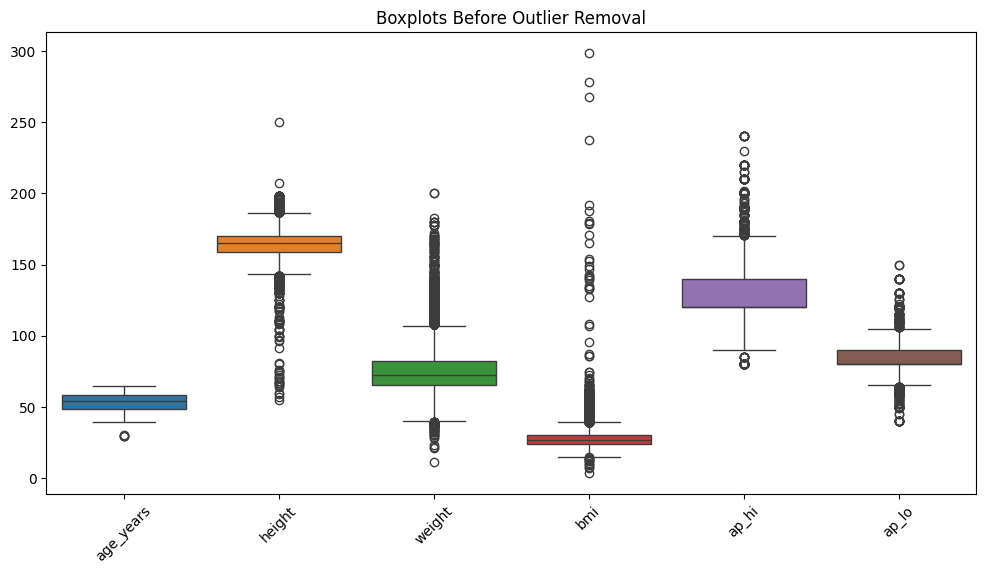

Cleaned dataset size: (68662, 15)
Dataset size after outlier removal: (61339, 15)
Rows removed as outliers: 7323


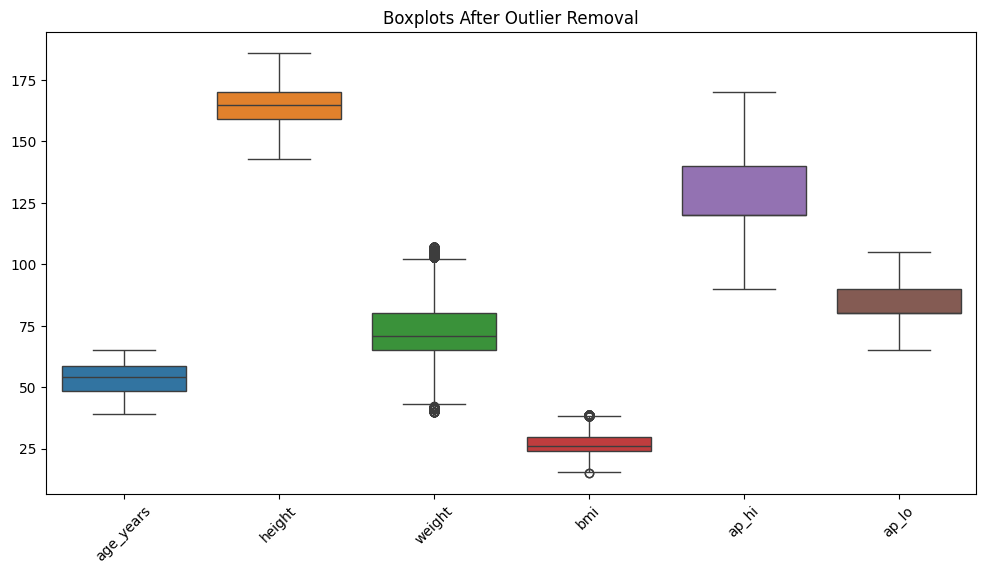

In [9]:
##part 3 outliers
outlier_cols = ["age_years", "height", "weight", "bmi", "ap_hi", "ap_lo"]
print("IQR outlier counts:")

for col in outlier_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df_clean[(df_clean[col] < lower) | (df_clean[col] > upper)]
    print(f"{col}: {len(outliers)} outliers")

#outlier detection using z score method
z_scores = np.abs(stats.zscore(df_clean[outlier_cols]))
z_outliers = (z_scores > 3).sum(axis=0)

print("Z-score outlier counts:")
for col, count in zip(outlier_cols, z_outliers):
    print(f"{col}: {count} outliers")

##boxplots before removing outliers
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_clean[outlier_cols])
plt.title("Boxplots Before Outlier Removal")
plt.xticks(rotation=45)
plt.show()

#removing outliers using IQR method
df_no_outliers = df_clean.copy()
for col in outlier_cols:
    Q1 = df_no_outliers[col].quantile(0.25)
    Q3 = df_no_outliers[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_no_outliers = df_no_outliers[
    (df_no_outliers[col] >= lower) &
    (df_no_outliers[col] <= upper)
    ]
print("Cleaned dataset size:", df_clean.shape)
print("Dataset size after outlier removal:", df_no_outliers.shape)
print("Rows removed as outliers:", df_clean.shape[0] - df_no_outliers.shape[0])

##boxplots after removing outliers
plt.figure(figsize=(12,6))
sns.boxplot(data=df_no_outliers[outlier_cols])
plt.title("Boxplots After Outlier Removal")
plt.xticks(rotation=45)
plt.show()

Explained variance by each principal component:
PC1: 20.49%
PC2: 16.11%
PC3: 11.16%
PC4: 10.67%
PC5: 9.13%
PC6: 8.24%
PC7: 7.38%
PC8: 5.50%
PC9: 4.49%
PC10: 4.17%
PC11: 2.19%
PC12: 0.46%

First two PCs together:
PC1 + PC2: 36.61%


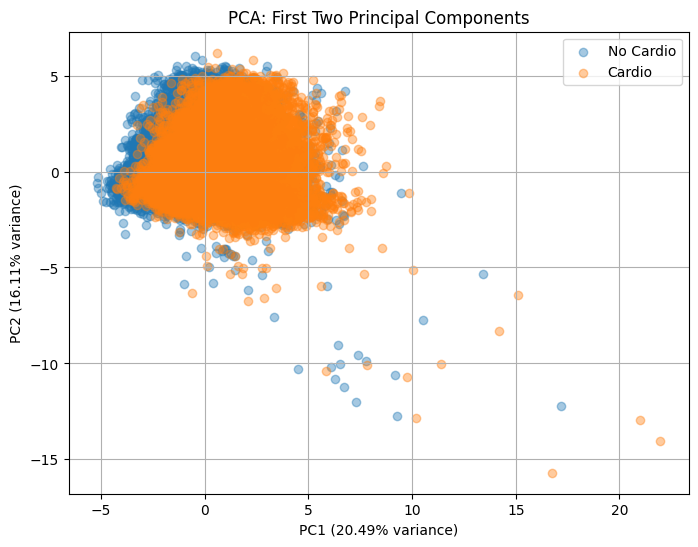


PCA Loadings:


,PC1 Loading,PC2 Loading
age_years,0.194127,-0.145146
height,0.049437,0.534738
weight,0.462958,0.104107
bmi,0.420713,-0.198288
ap_hi,0.467185,-0.020179
ap_lo,0.448875,-0.002724
cholesterol,0.285021,-0.133458
gluc,0.216031,-0.114491
smoke,0.072141,0.446731
alco,0.083988,0.321525



Variables contributing most to PC1:


,PC1 Loading,PC2 Loading
ap_hi,0.467185,-0.020179
weight,0.462958,0.104107
ap_lo,0.448875,-0.002724
bmi,0.420713,-0.198288
cholesterol,0.285021,-0.133458
gluc,0.216031,-0.114491
age_years,0.194127,-0.145146
gender,0.092501,0.555030
alco,0.083988,0.321525
smoke,0.072141,0.446731



Variables contributing most to PC2:


,PC1 Loading,PC2 Loading
gender,0.092501,0.555030
height,0.049437,0.534738
smoke,0.072141,0.446731
alco,0.083988,0.321525
bmi,0.420713,-0.198288
age_years,0.194127,-0.145146
cholesterol,0.285021,-0.133458
gluc,0.216031,-0.114491
weight,0.462958,0.104107
active,-0.008328,0.022200


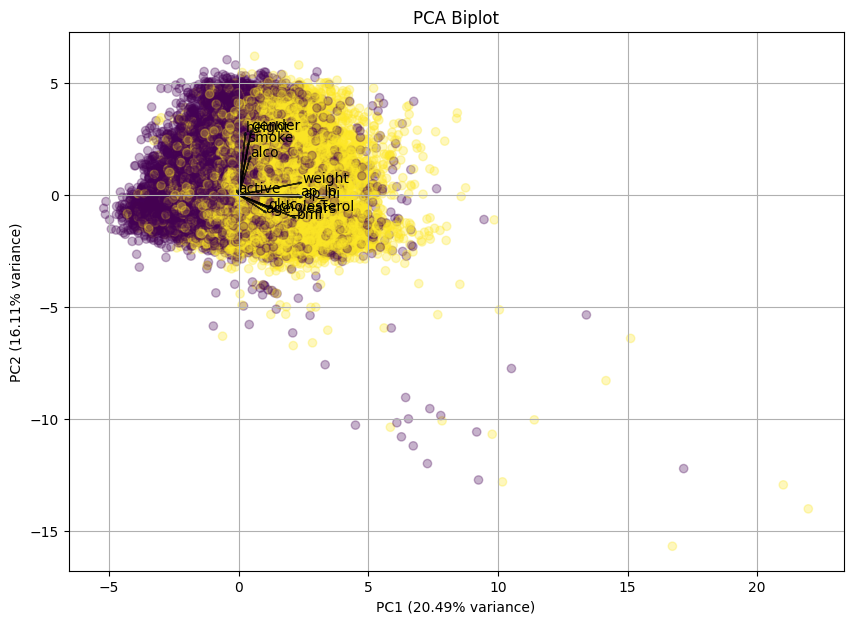

In [10]:
##Part 4: Principal Component Analysis (PCA)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 
#Load the dataset
# 
df = pd.read_csv("cardio_train.csv", sep=";")

# 
#Create useful variables
# 
df["age_years"] = df["age"] / 365.25
df["bmi"] = df["weight"] / ((df["height"] / 100) ** 2)

# 
#Clean unrealistic blood pressure values
# 
df_bp = df[
    (df["ap_hi"] >= 80) &
    (df["ap_hi"] <= 250) &
    (df["ap_lo"] >= 40) &
    (df["ap_lo"] <= 150) &
    (df["ap_hi"] > df["ap_lo"])
].copy()

# 
#  variables for PCA
# Not including cardio because PCA should be on predictors
# 
features = [
    "age_years",
    "height",
    "weight",
    "bmi",
    "ap_hi",
    "ap_lo",
    "cholesterol",
    "gluc",
    "smoke",
    "alco",
    "active",
    "gender"
]

X = df_bp[features]


#Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


#Perform PCA

pca = PCA()
pca_result = pca.fit_transform(X_scaled)


#Explained variance

explained_variance = pca.explained_variance_ratio_

print("Explained variance by each principal component:")
for i, var in enumerate(explained_variance):
    print(f"PC{i+1}: {var*100:.2f}%")

print("\nFirst two PCs together:")
print(f"PC1 + PC2: {(explained_variance[0] + explained_variance[1]) * 100:.2f}%")


#Create PCA dataframe
pca_df = pd.DataFrame(
    pca_result[:, 0:2],
    columns=["PC1", "PC2"]
)

pca_df["cardio"] = df_bp["cardio"].values


plt.figure(figsize=(8, 6))

plt.scatter(
    pca_df[pca_df["cardio"] == 0]["PC1"],
    pca_df[pca_df["cardio"] == 0]["PC2"],
    alpha=0.4,
    label="No Cardio"
)

plt.scatter(
    pca_df[pca_df["cardio"] == 1]["PC1"],
    pca_df[pca_df["cardio"] == 1]["PC2"],
    alpha=0.4,
    label="Cardio"
)

plt.xlabel(f"PC1 ({explained_variance[0]*100:.2f}% variance)")
plt.ylabel(f"PC2 ({explained_variance[1]*100:.2f}% variance)")
plt.title("PCA: First Two Principal Components")
plt.legend()
plt.grid(True)
plt.show()


loadings = pd.DataFrame(
    pca.components_[0:2].T,
    columns=["PC1 Loading", "PC2 Loading"],
    index=features
)

print("\nPCA Loadings:")
display(loadings)

print("\nVariables contributing most to PC1:")
display(loadings.reindex(loadings["PC1 Loading"].abs().sort_values(ascending=False).index))

print("\nVariables contributing most to PC2:")
display(loadings.reindex(loadings["PC2 Loading"].abs().sort_values(ascending=False).index))

#Biplot

plt.figure(figsize=(10, 7))

# Plot PCA scores
plt.scatter(
    pca_result[:, 0],
    pca_result[:, 1],
    c=df_bp["cardio"],
    alpha=0.3
)

# Plot loading vectors
for i, feature in enumerate(features):
    plt.arrow(
        0,
        0,
        pca.components_[0, i] * 5,
        pca.components_[1, i] * 5,
        head_width=0.08,
        alpha=0.8
    )
    plt.text(
        pca.components_[0, i] * 5.3,
        pca.components_[1, i] * 5.3,
        feature,
        fontsize=10
    )

plt.xlabel(f"PC1 ({explained_variance[0]*100:.2f}% variance)")
plt.ylabel(f"PC2 ({explained_variance[1]*100:.2f}% variance)")
plt.title("PCA Biplot")
plt.grid(True)
plt.show()

In [11]:
## Part 5: MoM and MLE

x = np.array([2.1,1.9,2.5,1.7,2.0])
n = len(x)
# MoM estimates 
mu_mom = np.mean(x)
sigma2_mom = np.mean((x - mu_mom) ** 2)

#MLE estimates
mu_mle = np.mean(x)
sigma2_mle = np.mean((x - mu_mle) ** 2)
print("Sample data:", x)
print("n =", n)
print("\nMethod of Moments (MoM) Estimates:")
print("mu_hat =", round(mu_mom, 4))
print("sigma^2_hat =", round(sigma2_mom, 4))
print("\nMaxmimum Likelihood Estimate (MLE):")
print("mu_hat =", round(mu_mle, 4))
print("sigma^2_hat =", round(sigma2_mle, 4))

print("\nComparison:")
if np.isclose(mu_mom, mu_mle) and np.isclose(sigma2_mom, sigma2_mle):
    print("The MoM and MLE estimates are the same.")
else:
    print("The MoM and MLE estimates are different.")

Sample data: [2.1 1.9 2.5 1.7 2. ]
n = 5

Method of Moments (MoM) Estimates:
mu_hat = 2.04
sigma^2_hat = 0.0704

Maxmimum Likelihood Estimate (MLE):
mu_hat = 2.04
sigma^2_hat = 0.0704

Comparison:
The MoM and MLE estimates are the same.


In [12]:
##Part 6: Monte Carlo simulation
np.random.seed(123)
##generate 10,000 random samples

samples_10000 = np.random.normal(0, 1, 10000)

#estimate P(X > 1)
prob_10000 = np.mean(samples_10000 > 1)
print("estimated P(X > 1) using 10,000 samples:", prob_10000)
print("true value: approx. 0.1587")

##repeat simulation with 100,000 samples
np.random.seed(123)
samples_100000 = np.random.normal(0, 1, 100000)
prob_100000 = np.mean(samples_100000 > 1)
print("estimated P(X > 1) using 100,000 samples:", prob_100000)
print("true value: approx. 0.1587")

#compare estimates
monte_carlo_results = pd.DataFrame({
    "Sample Size": [10000, 100000],
    "Estimated P(X > 1)": [prob_10000, prob_100000],
    "True Value": [0.1587, 0.1587],
    "Absolute Error": [abs(prob_10000 - 0.1587), abs(prob_100000 - 0.1587)]
})
monte_carlo_results

estimated P(X > 1) using 10,000 samples: 0.1593
true value: approx. 0.1587
estimated P(X > 1) using 100,000 samples: 0.1602
true value: approx. 0.1587


,Sample Size,Estimated P(X > 1),True Value,Absolute Error
0,10000,0.1593,0.1587,0.0006
1,100000,0.1602,0.1587,0.0015


Final x estimate after 5 iterations: 2.01696
Final function value: 0.9663676415999999
True minimum occurs at x = 3
True minimum values is f(3) = 0


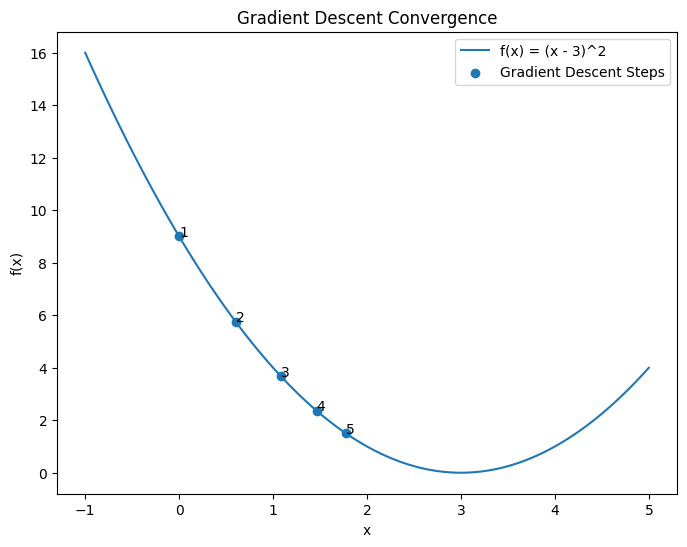

In [13]:
##part 7 gradient descent

#define the function
def f(x):
    return (x - 3) ** 2

#define the derivative
def derivative_f(x):
    return 2 * (x - 3)

#initial value and learning rate
x = 0
learning_rate = 0.1 
iterations = 5

#store results
gradient_descent_results = []

for i in range(iterations):
    gradient = derivative_f(x)
    new_x = x - learning_rate * gradient 
    gradient_descent_results.append({
    "Iteration": i + 1,
    "x value": x,
    "f(x)": f(x),
    "gradient": gradient,
    "new x value": new_x
    })
    x = new_x
gradient_descent_df = pd.DataFrame(gradient_descent_results)
gradient_descent_df

##final estimate after 5 iterations
print("Final x estimate after 5 iterations:", x)
print("Final function value:", f(x))
print("True minimum occurs at x = 3")
print("True minimum values is f(3) = 0")

#plot the function and gradient descent points :)
x_values = np.linspace(-1, 5, 100)
y_values = f(x_values)
plt.figure(figsize=(8,6))
plt.plot(x_values, y_values, label="f(x) = (x - 3)^2")

#plot gradient descent pts
gd_x_values = gradient_descent_df["x value"]
gd_y_values = gradient_descent_df["f(x)"]

plt.scatter(gd_x_values, gd_y_values, label="Gradient Descent Steps")
for i in range(len(gd_x_values)):
    plt.text(gd_x_values.iloc[i], gd_y_values.iloc[i], str(i + 1))

plt.title("Gradient Descent Convergence")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.show()